In [75]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import os

In [76]:
print(os.getcwd())
df = pd.read_csv("decision_tree.csv")
print(df.head())
for column in df.columns:
    print(df[column].dtype)

f:\AI_ML\Python projects\AI Assignments\Practise\01 Machine Learning\05 Decision Tree
   Day Weather Temperat Humidity    Wind Play
0    1   Sunny      Hot     High    Weak   No
1    2   Sunny      Hot     High  Strong   No
2    3  Cloudy      Hot     High    Weak  Yes
3    4    Rain     Mild     High    Weak  Yes
4    5    Rain     Cool   Normal    Weak  Yes
int64
object
object
object
object
object


In [77]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Day       14 non-null     int64 
 1   Weather   14 non-null     object
 2   Temperat  14 non-null     object
 3   Humidity  14 non-null     object
 4   Wind      14 non-null     object
 5   Play      14 non-null     object
dtypes: int64(1), object(5)
memory usage: 804.0+ bytes
None


In [78]:
le_dict = {}
for column in df.columns:
    if df[column].dtype == 'object':
        le = LabelEncoder()
        df[column] = le.fit_transform(df[column])
        le_dict[column] = le

In [79]:
X = df.drop(['Day','Play'],axis=1)
y = df['Play']

In [80]:
model = DecisionTreeClassifier(criterion='entropy', max_depth=3)
model.fit(X,y)

,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


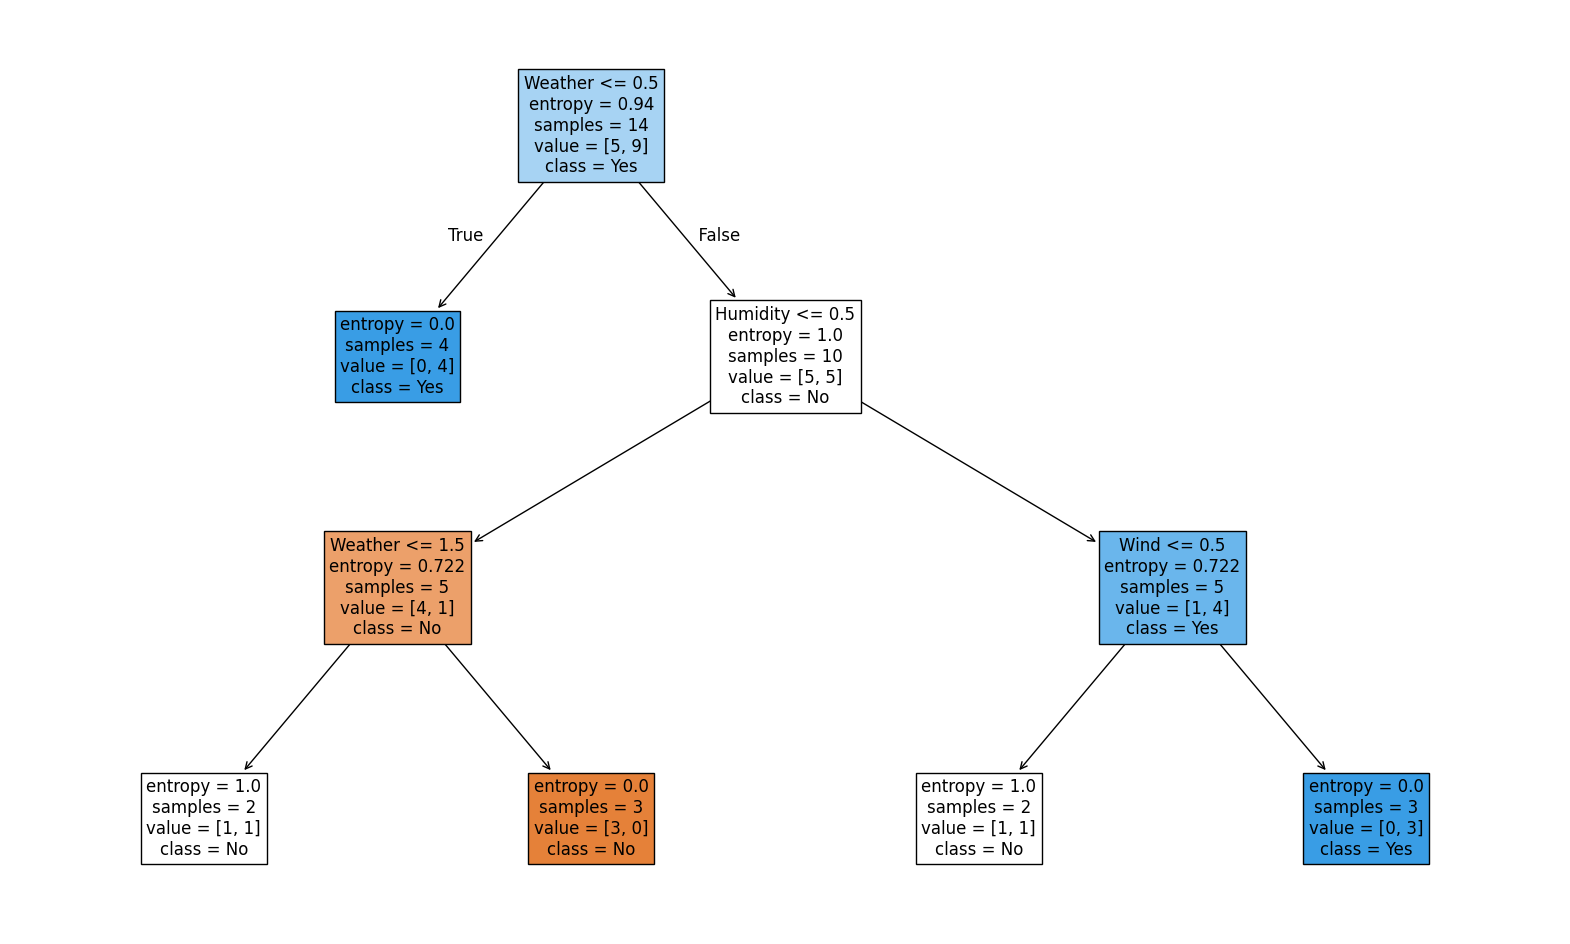

In [81]:
plt.figure(figsize=(20,12))
plot_tree(model,
    feature_names=X.columns,
    class_names=le_dict['Play'].classes_,
    filled=True,
    fontsize=12)
plt.show()

In [84]:

def predict_play(weather, temperature, humidity, wind): # Encode user input using the same label encoders
    w = le_dict['Weather'].transform([weather])[0]
    t = le_dict['Temperat'].transform([temperature])[0]
    h = le_dict['Humidity'].transform([humidity])[0]
    wi = le_dict['Wind'].transform([wind])[0]

    user_input = pd.DataFrame([[w, t, h, wi]], columns=X.columns)

    prediction = model.predict(user_input)[0]
    return le_dict['Play'].inverse_transform([prediction])[0]


In [87]:
print(predict_play("Cloudy", "Hot", "Normal", "Weak"))
print(predict_play("Rain", "Mild", "High", "Strong"))

Yes
No
